# Flower Classification CNN

In [1]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
import PIL
import cv2

import warnings 
warnings.filterwarnings('ignore')

## 1. Downloading images

In [2]:
dataset_link = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

dataset_dir = keras.utils.get_file(fname = 'flower_photos', origin = dataset_link,
                                   cache_dir = '.', untar =True)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


## 2. Preping image

In [3]:
import pathlib

datadir = pathlib.Path(dataset_dir)
datadir

PosixPath('datasets/flower_photos')

In [4]:
flowers = {'daisy': list(datadir.glob("flower_photos/daisy/*")),
           'dandelion': list(datadir.glob("flower_photos/dandelion/*")),
           'roses': list(datadir.glob("flower_photos/roses/*")),
           'sunflowers': list(datadir.glob("flower_photos/sunflowers/*")),
           'tulips': list(datadir.glob("flower_photos/tulips/*"))}

In [5]:
labels = {
    'daisy' : 0,
    'dandelion' : 1,
    'roses' : 2,
    'sunflowers' : 3,
    'tulips' : 4
}

# 3. Flowers !!!

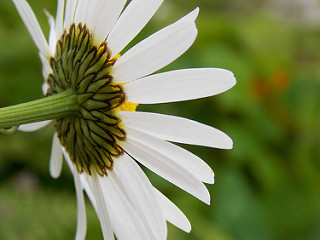

In [6]:
PIL.Image.open(str(flowers['daisy'][0]))
# the 0 is the 0th image

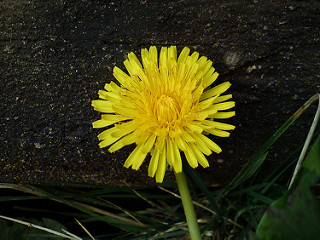

In [7]:
PIL.Image.open(str(flowers['dandelion'][0]))

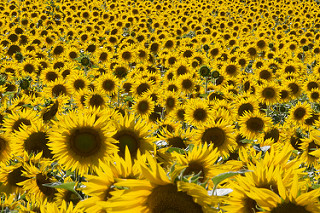

In [8]:
PIL.Image.open(str(flowers['sunflowers'][0]))

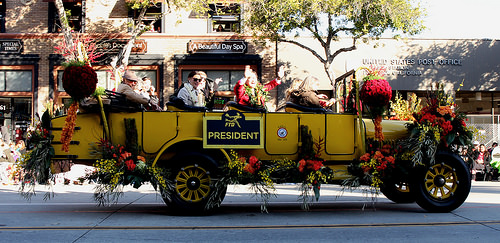

In [9]:
PIL.Image.open(str(flowers['roses'][0]))

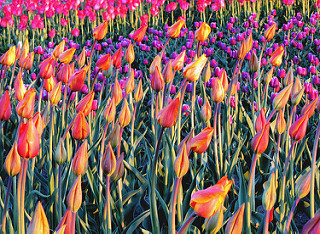

In [10]:
PIL.Image.open(str(flowers['tulips'][0]))

## 4. Extracting the data and labels

In [11]:
x = []
y = []          #should be quite similar as the x y features

for image_names, image in flowers.items():
    for img in image:
        img = cv2.imread(str(img)) 
        resized = cv2.resize(img, (224,224))
        x.append(resized)
        y.append(labels[image_names])

x = np.array(x)         #make array
y = np.array(y)

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, stratify=y)

# stratify=y -> make sure the distribution of labels in y stays same for test and train

In [13]:
# scale the data, making the pixel values smaller for model to learn easier
x_train_scaled = x_train / 255
x_test_scaled = x_test / 255

## 5. Building CNN

In [14]:
from tensorflow.keras import layers

# creating sequential block of image transformation
data_aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal', input_shape = (224,224,3)),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

# 1. Flip image horizontally (pixel height, pixel width, color channel)
# 2. Rotate image random up to 20%
# 3. Zoom image random up to 20%

2025-05-26 22:11:05.126408: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-05-26 22:11:05.126438: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-05-26 22:11:05.126440: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2025-05-26 22:11:05.126459: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-26 22:11:05.126468: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [15]:
model = keras.models.Sequential([
    data_aug,
# the 16, 32, 64 are number of filters AKA feature maps (eg. 16 = 16 different filters)
    keras.layers.Conv2D(filters = 16, kernel_size = (3,3), activation = 'relu', padding = 'same'), #detect simple features(edges, color) and reduce image size
    keras.layers.MaxPool2D((3,3)),
    keras.layers.Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu'), #more complex patterns
    keras.layers.MaxPool2D((3,3)),
    keras.layers.Dropout(0.2), #drop 20% prevent overfitting
    keras.layers.Conv2D(filters = 64, kernel_size = (3,3), activation = 'relu', padding ='same'), #
    keras.layers.MaxPool2D((3,3)),
    keras.layers.Conv2D(filters = 128, kernel_size = (3,3), activation = 'relu', padding ='same'),
    keras.layers.MaxPool2D((3,3)),
    keras.layers.Dropout(0.2),
# Conv2D kernel_size (3,3) =  each filter learn pattern in 3x3 window
# MaxPool2D (3,3) = shrink the image
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation= 'relu'),
    keras.layers.Dense(32, activation= 'relu'),
    keras.layers.Dense(5, activation= 'softmax')
])

In [16]:
model.compile(
    optimizer = 'adam', #common optimizer for deeplearn
    loss = 'sparse_categorical_crossentropy', # 
    metrics = ['accuracy'] #show accuracy during training & eval
)

In [17]:
model.fit(x_train_scaled, y_train, epochs = 30)
# epochs = x times running through the entire data (too much may overfit)

Epoch 1/30


2025-05-26 22:11:06.481120: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.2231 - loss: 1.6179
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3194 - loss: 1.7626
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3811 - loss: 1.4284
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.2845 - loss: 2.2687
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.2802 - loss: 3.0158
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3508 - loss: 4.4409
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3519 - loss: 6.3277
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3376 - loss: 15.0745
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.2905 - loss: 99.7217
Epoch 10/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.2463 - loss: 176.1232
Epoch 11/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.2854 - loss: 127.0202
Epoch 12/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.28

## 6. Evalutating

In [18]:
model.evaluate(x_test_scaled, y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3823 - loss: 24.9323


[23.679580688476562, 0.3732970058917999]

Here we got:
1. Loss: (lower the better)
    - 0.0 to 0.3 very low, model is confident and correct
    - 0.3 to 0.7 medium loss, model getting better
    - 0.7 to 1.5 high loss, model makes frequent or confident mistakes
    - ">=" 2 very high loss, might be guessing randomly
2. Accuracy: (x % accurate)

### 6.1 Confusion Matrix

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


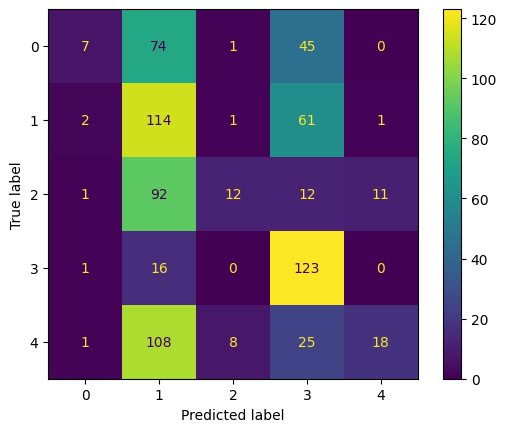

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 1. Predict on the test data
y_pred_probs = model.predict(x_test_scaled)  # returns probabilities
y_pred = np.argmax(y_pred_probs, axis=1)     # get predicted class

# 2. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

### 6.2 Verdict
Model is terrible hahahhaa

## 7. Transfer Learning (improve performance)

In [20]:
# here we are basically reusing other trained model's knowledge to improve performance
# using pretrained models can save quite a bit of time

In [21]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# MobileNetV2 used
from tensorflow.keras.applications import MobileNetV2

pretrained_layer = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')
pretrained_layer.trainable = False # freeze the base model

In [28]:
pretrained_model = keras.Sequential([
    pretrained_layer,
    layers.GlobalAveragePooling2D(),
    keras.layers.Dense(5, activation= 'softmax')
])

In [29]:
pretrained_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [31]:
pretrained_model.fit(x_train_scaled, y_train, epochs = 10)
# since the base model is frozen, there's no need for too many epochs

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9788 - loss: 0.1182
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9851 - loss: 0.1067
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9849 - loss: 0.1004
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9883 - loss: 0.0966
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9924 - loss: 0.0809
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9921 - loss: 0.0759
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9918 - loss: 0.0757
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9934 - loss: 0.0703
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9937 - loss: 0.0662
Epoch 10/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9943 - loss: 0.0597


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


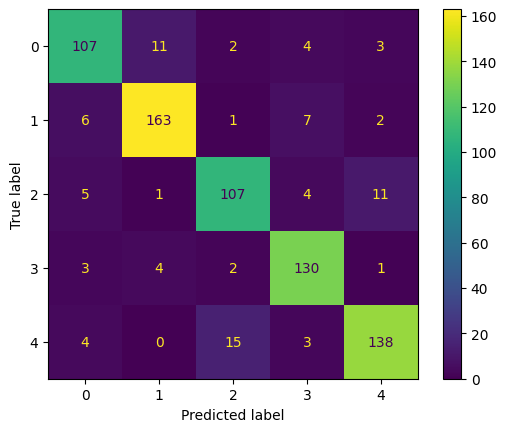

In [34]:
y_pred_probs = pretrained_model.predict(x_test_scaled)  # returns probabilities
y_pred = np.argmax(y_pred_probs, axis=1)     # get predicted class

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

Major improvement but this accuracy seems too good to be true??

In [37]:
history = pretrained_model.fit(x_train_scaled, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9926 - loss: 0.0589 - val_accuracy: 1.0000 - val_loss: 0.0569
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9954 - loss: 0.0552 - val_accuracy: 0.9949 - val_loss: 0.0621
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9955 - loss: 0.0485 - val_accuracy: 0.9966 - val_loss: 0.0677
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9981 - loss: 0.0453 - val_accuracy: 0.9898 - val_loss: 0.0718
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9952 - loss: 0.0467 - val_accuracy: 0.9898 - val_loss: 0.0711
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9988 - loss: 0.0390 - val_accuracy: 0.9813 - val_loss: 0.0790
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9985 - loss: 0.0372 - val_accuracy: 0.9864 - val_loss: 0.0798
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9993 - loss: 0.0373 - val_accuracy: 0.9830 - v

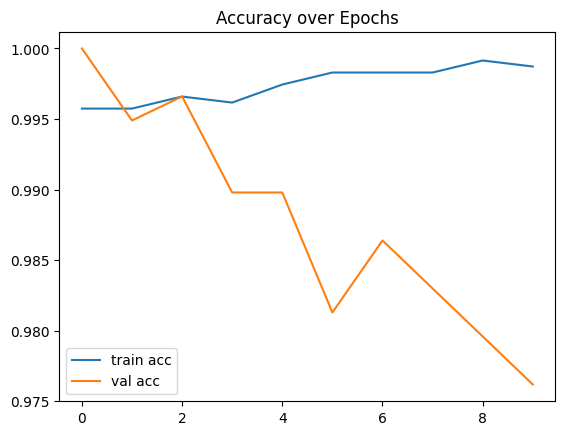

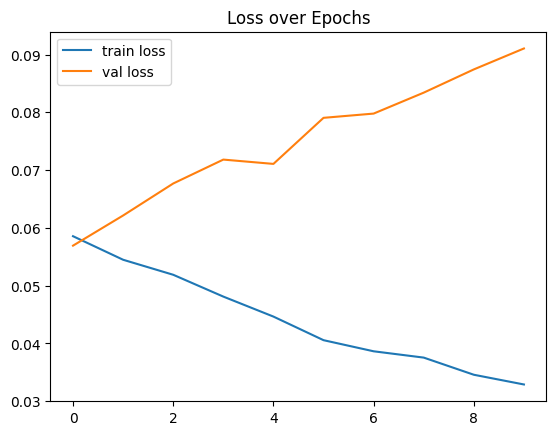

In [38]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history.get('val_accuracy'), label='val acc')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history.get('val_loss'), label='val loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

Here we see the model is definitely overfitting, the training loss does decrease but the validation loss increased

This means the model will perform worse on unseen data

## 8. Fixing the overfit

In [39]:
from tensorflow.keras import layers

pretrained_model_second = keras.Sequential([
    pretrained_layer,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),                
    layers.Dense(5, activation='softmax')
])

#here we add dropout in the model, see if it fixes it

In [42]:
pretrained_model_second.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [43]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = pretrained_model_second.fit(
    x_train_scaled, y_train,
    validation_split=0.2,
    epochs=30,
    callbacks=[early_stop]
)

# early stopping also used

Epoch 1/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.4785 - loss: 1.3163 - val_accuracy: 0.7721 - val_loss: 0.6236
Epoch 2/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.7657 - loss: 0.6265 - val_accuracy: 0.8061 - val_loss: 0.5397
Epoch 3/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8303 - loss: 0.4848 - val_accuracy: 0.8197 - val_loss: 0.4793
Epoch 4/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8546 - loss: 0.4226 - val_accuracy: 0.8248 - val_loss: 0.4854
Epoch 5/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8713 - loss: 0.3796 - val_accuracy: 0.8316 - val_loss: 0.4615
Epoch 6/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8793 - loss: 0.3371 - val_accuracy: 0.8435 - val_loss: 0.4417
Epoch 7/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8848 - loss: 0.3116 - val_accuracy: 0.8452 - val_loss: 0.4392
Epoch 8/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9090 - loss: 0.2567 - val_accuracy: 0.8384 - v

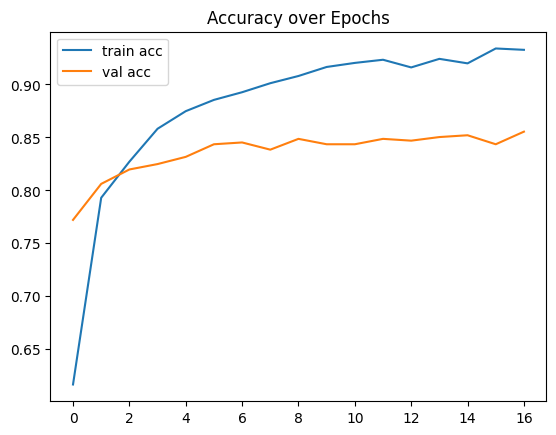

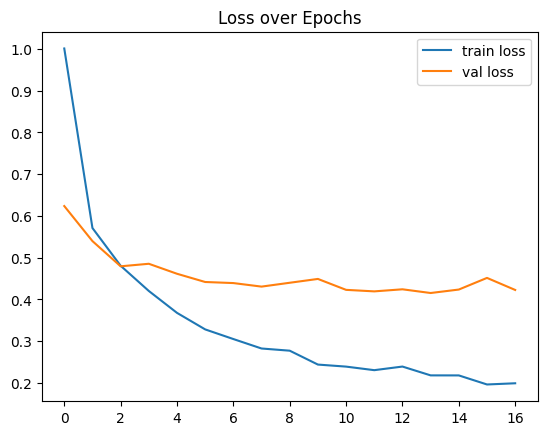

In [44]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history.get('val_accuracy'), label='val acc')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history.get('val_loss'), label='val loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step


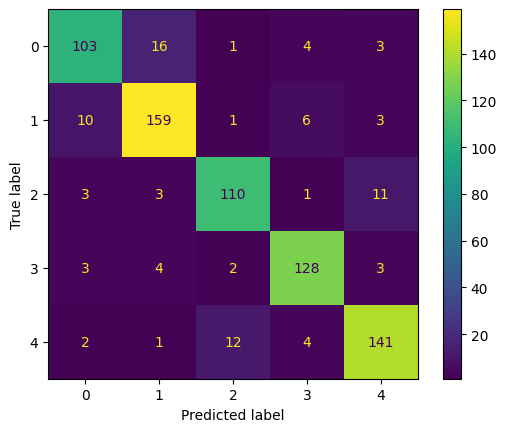

In [45]:
y_pred_probs = pretrained_model_second.predict(x_test_scaled)  # returns probabilities
y_pred = np.argmax(y_pred_probs, axis=1)     # get predicted class

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

The loss over epochs looks better now, we settle with this

In [46]:
pretrained_model_second.evaluate(x_test_scaled, y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.8705 - loss: 0.4107


[0.37985774874687195, 0.8732969760894775]

## 9. Summary

We sum up with a model of:
1. Loss; 0.37 (good, but room for improvement)
2. 87.33% accuracy (ok score)

## 10. Extra (input function)

In [54]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Replace with your actual class labels
class_names = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

def predict_image(img_path, pretrained_model_second):
    # Load and resize the image
    img = image.load_img(img_path, target_size=(224, 224))
    
    # Convert to array
    img_array = image.img_to_array(img)
    
    # Scale pixel values to 0–1
    img_array = img_array / 255.0
    
    # Add batch dimension (1, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Make prediction
    prediction = pretrained_model_second.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    return predicted_class, confidence

In [55]:
result, conf = predict_image("/Users/adrian/Desktop/Projects/Flower_Image_Classification/testcase/photograph-of-a-rose-1024x771.webp", pretrained_model_second)
print(f"Prediction: {result} ({conf:.2%} confidence)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Prediction: rose (99.70% confidence)
